##

## Limitation for Experimental is you have improve model don't have use feature more than Baseline

In [132]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import shap

In [133]:
# machine learning regression
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, StratifiedKFold, KFold, RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans
from sklearn.base import clone

from xgboost import XGBRegressor , XGBClassifier
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

In [134]:
import warnings
from sklearn.exceptions import DataConversionWarning
# -----------------------------
# ปิด warning
# -----------------------------
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [135]:
#=========================================================
#  Load dataset and checking nan
#=========================================================

df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
print(f"total number of rows and columns in the dataset: {len(df_original.columns) + 1} columns, {len(df_original) + 1} rows")


# Grouping years into decodes
def Grouping_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Grouping_year = Grouping_date_to_year(df_original)

# Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

Missing  = nan_check(df_Grouping_year)
Missing

total number of rows and columns in the dataset: 49 columns, 9666 rows
Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


,Total,%
City_Town_3,8728,90.3
City_Town_2,4943,51.1
City_Town,437,4.5
State_Island_Province,36,0.4
SSTA_Minimum,12,0.1
SSTA_FrequencyMax,5,0.1
SSTA_Standard_Deviation,5,0.1
TSA_Maximum,5,0.1
SSTA_Maximum,5,0.1
SSTA_Frequency,5,0.1


In [136]:
for i in df_original.dtypes.index:
    print(i, df_original.dtypes[i])

ID int64
Latitude_Degrees float64
Longitude_Degrees float64
Ocean str
Realm str
Ecoregion str
Country_Name str
State_Island_Province str
City_Town str
City_Town_2 str
City_Town_3 str
Date datetime64[us]
Date2 int64
Depth float64
Average_Bleaching float64
ClimSST float64
Temperature_Kelvin float64
Temperature_Mean float64
Temperature_Minimum float64
Temperature_Maximum float64
Temperature_Kelvin_Standard_Deviation float64
Windspeed float64
SSTA float64
SSTA_Standard_Deviation float64
SSTA_Mean float64
SSTA_Minimum float64
SSTA_Maximum float64
SSTA_Frequency float64
SSTA_Frequency_Standard_Deviation float64
SSTA_FrequencyMax float64
SSTA_FrequencyMean float64
SSTA_DHW float64
SSTA_DHW_Standard_Deviation float64
SSTA_DHWMax float64
SSTA_DHWMean float64
TSA float64
TSA_Standard_Deviation float64
TSA_Minimum float64
TSA_Maximum float64
TSA_Mean float64
TSA_Frequency float64
TSA_Frequency_Standard_Deviation float64
TSA_FrequencyMax float64
TSA_FrequencyMean float64
TSA_DHW float64
TSA_DHW_St

In [137]:
#=================================================
# Function analysis variable for Cleaning data
#=================================================
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    type_object = df_dtype.select_dtypes(include=['object']).columns.tolist()

    type_number = df_dtype.select_dtypes(
        include=['number']
    ).columns.tolist()

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Name_of_moreNAN : {len(Index_more)} attribuue : {Index_more}")
    print(f"Name_of_lessNAN : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_original, '%')
print("="*80)
print(">>>>>>>  Missing values more than 0.4% : Delete <<<<<<<<")
print("="*80)



more than 0.4% : 4
less than 0.4% : 45
Name_of_moreNAN : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Name_of_lessNAN : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City

C:\Users\superuser\AppData\Local\Temp\ipykernel_18732\714703545.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  type_object = df_dtype.select_dtypes(include=['object']).columns.tolist()


In [138]:
#=========================================
# Cleaning data
#=========================================
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

col_dont_need = ['ID', 'Date', 'Date2', 'SSTA_Mean']
df_Clean_already = Clean_data_paper(df_Grouping_year, col_object, col_dont_need)
df_Clean_already = df_Clean_already.ffill()
print("="*200)
print(f"{col_object} >>>>> {col_dont_need} : {len(col_object) + len(col_dont_need)} >>>>>>>> {len(df_original.columns) - len(col_object) - len(col_dont_need)}")
print(f"total number of rows and columns in the dataset: {len(df_Clean_already.columns)} columns, {len(df_Clean_already)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")
print("="*200)

['Ocean', 'Realm', 'Ecoregion', 'Country_Name', 'State_Island_Province', 'City_Town', 'City_Town_2', 'City_Town_3'] >>>>> ['ID', 'Date', 'Date2', 'SSTA_Mean'] : 12 >>>>>>>> 37
total number of rows and columns in the dataset: 37 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


## ***ตัวแปรที่เก็บ data เเละพร้อมใช้งานสำหรับการนำไปวิเคราะห์ df_Clean_already***

In [139]:
df_Clean_already

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
0,-20.899833,149.407722,4.0,6.25,297.78,301.670,298.17,291.910000,303.850,2.740,...,-3.260,3.0,1.950,7.000000,1.0,3.52,1.360000,8.43,0.520000,2016
1,-20.893056,149.421000,5.0,8.75,297.78,301.670,298.17,291.910000,303.850,2.740,...,-3.260,3.0,1.950,7.000000,1.0,3.52,1.360000,8.43,0.520000,2016
2,-20.745806,149.472056,6.0,11.25,298.17,301.380,298.34,292.670000,303.760,2.570,...,-3.060,1.0,1.470,5.000000,1.0,1.51,1.230000,7.32,0.490000,2016
3,-20.737694,149.464944,5.0,25.00,298.21,301.560,298.37,292.010000,304.040,2.520,...,-3.010,2.0,1.310,5.000000,1.0,2.36,0.970000,6.86,0.360000,2016
4,-20.259361,148.814583,2.0,1.00,296.48,296.380,298.47,291.830000,304.540,2.700,...,-3.230,4.0,1.720,7.000000,1.0,0.00,1.470000,9.84,0.560000,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9641,20.738889,107.058333,3.2,0.00,262.15,302.955,298.07,288.423333,306.535,4.495,...,-5.255,0.0,1.645,7.333333,1.0,0.00,1.381667,11.57,0.446667,2003
9646,20.845833,107.177778,3.0,0.00,299.80,302.300,298.09,289.690000,307.260,4.360,...,-5.080,0.0,2.180,11.000000,1.0,0.00,1.740000,12.00,0.640000,2003
9649,12.601722,53.817306,6.0,0.00,301.40,302.670,299.38,294.550000,309.550,1.980,...,-3.240,0.0,1.400,6.000000,0.0,0.00,1.710000,19.41,0.370000,2008
9663,15.701611,42.391806,9.0,0.00,304.39,303.890,301.97,296.610000,307.200,2.400,...,-2.690,0.0,1.630,6.000000,1.0,0.00,1.330000,8.30,0.540000,2008


##

##

##

## Modeling

In [140]:
def PLOTING_RESULT_ML(model, X_test, y_test, cl, name):

    y_pred = model.predict(X_test).ravel()
    y_test = np.array(y_test).ravel()

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_test,
        y=y_pred,
        alpha=0.5,
        color=cl,
        edgecolor='k'
    )

    # ideal line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red',
        linestyle='--',
        lw=2
    )

    plt.title(f'Actual vs Predicted Percent Bleaching : {name}')
    plt.xlabel('Actual Bleaching (%)')
    plt.ylabel('Predicted Bleaching (%)')

    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()
   
#=========================================================================================================================================================#
def feature_importance(model, feature_names):
    
    importance = model.feature_importances_
    feature_names_importance = feature_names.columns
    
    df_importance = pd.DataFrame({
        'feature' : feature_names_importance,
        'importance' : importance
    }).sort_values(by='importance', ascending=False)
    
    return df_importance

In [141]:
def Cross_validarion_regression(X_train, y_train, model, n_splits=5):

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    oof_preds = np.zeros(len(X_train))

    models = []

    rmse_scores = []
    mae_scores = []
    r2_scores = []

    y_train = np.array(y_train).ravel()

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):

        print(f"\n===== Fold {fold+1} / {n_splits} =====")

        # split
        X_tr = X_train[train_idx]
        X_val = X_train[val_idx]

        y_tr = y_train[train_idx]
        y_val = y_train[val_idx]
        
        # train
        reg = clone(model) 
        reg.fit(X_tr, y_tr)

        # predict
        pred = reg.predict(X_val)

        # save OOF
        oof_preds[val_idx] = pred

        # metrics
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        mae = mean_absolute_error(y_val, pred)
        r2 = r2_score(y_val, pred)

        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)

        models.append(reg)

        print(f"Fold RMSE : {rmse:.4f}")
        print(f"Fold MAE  : {mae:.4f}")
        print(f"Fold R2   : {r2:.4f}")
        
    print("\n")
    print(f"Mean RMSE : {np.mean(rmse_scores):.4f}")
    print(f"Mean MAE  : {np.mean(mae_scores):.4f}")
    print(f"Mean R2   : {np.mean(r2_scores):.4f}")
    
    print("="*50)

    return (
        models,
        oof_preds,
        rmse_scores,
        mae_scores,
        r2_scores
    )
    
#==================================================================================================================================================================================#


def Hyperparameter_tunning(X_train, y_train, model=RandomForestRegressor(random_state=42)):
    rf = model

    param_rf = {
        "n_estimators": [200, 300, 500, 800],
        "max_depth": [10, 15, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    }

    # 2. RandomizedSearchCV ทำ CV บน train เท่านั้น
    search_rf = RandomizedSearchCV(
        rf,
        param_rf,
        n_iter=30,
        cv=5,              # 5-fold บน X_train
        scoring="r2",
        n_jobs=-1,
        verbose=2,
        random_state=42
    )
    
    search_rf.fit(X_train, y_train)
    
    return search_rf

#==================================================================================================================================================================================#

def X_train_test_split(X, y, test_size=0.2, random_state=42):
    return train_test_split(X, y, test_size=test_size, random_state=random_state)


##

##

## Model 1th : Baseline 5 feature --> RF (tunning hyperparameter)

In [142]:
feature_paper = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'Depth_m', 'SSTA']
feature_Baseline = df_Clean_already[feature_paper]
target_Baseline = df_Clean_already['Percent_Bleaching']

algo_baseline = [
    [RandomForestRegressor(max_features = 'log2', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 300, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Baseline', 'green']
]

In [143]:
X_train_paper, X_test_paper, y_train_paper, y_test_paper = X_train_test_split(feature_Baseline.values, target_Baseline.values)


========== RandomForestRegressor_Baseline ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.4184
Fold MAE  : 3.3848
Fold R2   : 0.1772

===== Fold 2 / 5 =====
Fold RMSE : 8.2670
Fold MAE  : 3.5137
Fold R2   : 0.3263

===== Fold 3 / 5 =====
Fold RMSE : 8.2367
Fold MAE  : 3.3419
Fold R2   : 0.3127

===== Fold 4 / 5 =====
Fold RMSE : 8.1649
Fold MAE  : 3.2978
Fold R2   : 0.2327

===== Fold 5 / 5 =====
Fold RMSE : 7.6546
Fold MAE  : 3.3369
Fold R2   : 0.3549


Mean RMSE : 8.1483
Mean MAE  : 3.3750
Mean R2   : 0.2807


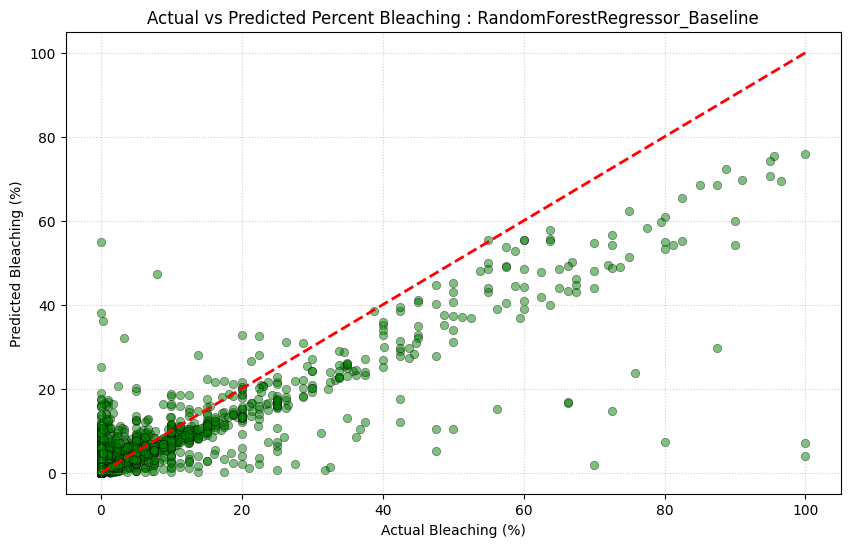


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.240621
0   Latitude_Degrees    0.219924
4               SSTA    0.215291
2            ClimSST    0.209221
3            Depth_m    0.114942


In [144]:
all_results_baseline = []

for model, model_name, color in algo_baseline:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_Baseline.values,
        target_Baseline.values,
        model,
        n_splits=5
    )

    all_results_baseline.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_Baseline.values,
        y_test=target_Baseline.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_Baseline)
print("\nFeature Importance:")
print(feature_importance_df)

##

##

## Model 1th : Drop depth feature becuase depth it less more permutation

In [145]:
factors_model2th = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA']
feature_model2th = df_Clean_already[factors_model2th]

algo_model2th = [
    [RandomForestRegressor(max_features = 'log2', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 300, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green']

]

In [146]:
X_train_model2th, X_test_model2th, y_train_model2th, y_test_model2th = X_train_test_split(feature_model2th.values, target_Baseline.values)


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====


Fold RMSE : 8.3586
Fold MAE  : 3.2356
Fold R2   : 0.1888

===== Fold 2 / 5 =====
Fold RMSE : 8.2364
Fold MAE  : 3.3517
Fold R2   : 0.3313

===== Fold 3 / 5 =====
Fold RMSE : 7.9681
Fold MAE  : 3.1392
Fold R2   : 0.3568

===== Fold 4 / 5 =====
Fold RMSE : 7.8323
Fold MAE  : 3.0704
Fold R2   : 0.2939

===== Fold 5 / 5 =====
Fold RMSE : 7.4271
Fold MAE  : 3.1439
Fold R2   : 0.3927


Mean RMSE : 7.9645
Mean MAE  : 3.1882
Mean R2   : 0.3127


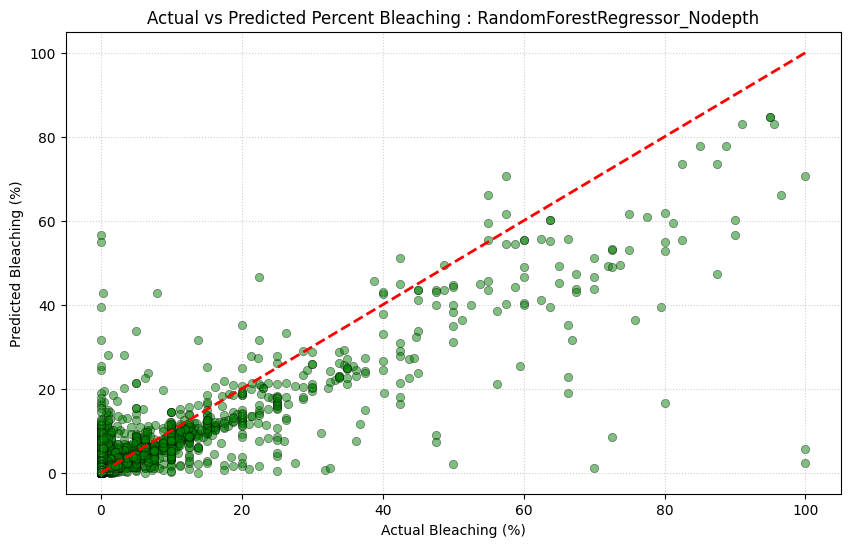


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.271895
3               SSTA    0.248116
0   Latitude_Degrees    0.242271
2            ClimSST    0.237718


In [147]:
all_results_model2th = []

for model, model_name, color in algo_model2th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model2th.values,
        target_Baseline.values,
        model,
        n_splits=5
    )

    all_results_model2th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model2th.values,
        y_test=target_Baseline.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model2th)
print("\nFeature Importance:")
print(feature_importance_df)

##

##

##

## Feature Engineering

In [148]:
df_Interaction = df_Clean_already.copy()

In [149]:
# Feature Engineering

df_Interaction['SSTA_X_ClimSST'] = df_Interaction['SSTA'] * df_Interaction['ClimSST']  #X1
df_Interaction['La_X_SSTA'] = df_Interaction['Latitude_Degrees'] * df_Interaction['SSTA'] #X2
df_Interaction['La_X_ClimSST'] = df_Interaction['Latitude_Degrees'] * df_Interaction['ClimSST'] #X3
df_Interaction['Long_X_ClimSST'] = (
    np.abs(df_Interaction['Longitude_Degrees']) * df_Interaction['ClimSST']
)
df_Interaction['is_tropical'] = (
    (np.abs(df_Interaction['Latitude_Degrees']) <= 23.5).astype(int) 
    * df_Interaction['Long_X_ClimSST']
)


In [150]:
factors_interaction = ['SSTA_X_ClimSST', 'La_X_SSTA', 'La_X_ClimSST', 'Long_X_ClimSST', 'is_tropical']
nan_check(df_Interaction[factors_interaction])

,Total,%
SSTA_X_ClimSST,0,0.0
La_X_SSTA,0,0.0
La_X_ClimSST,0,0.0
Long_X_ClimSST,0,0.0
is_tropical,0,0.0


In [151]:
tropical_mask = df_Interaction['Latitude_Degrees'].abs() <= 23.5
print("Min Longitude in tropical zone:", 
      df_Interaction[tropical_mask]['Longitude_Degrees'].min())
print("Negative longitude count:", 
      (df_Interaction[tropical_mask]['Longitude_Degrees'] < 0).sum())

Min Longitude in tropical zone: -179.8593611
Negative longitude count: 1527


In [152]:
# เช็คว่า NaN ถูก drop ไปโดยไม่รู้ตัวไหม
print("Before feature engineering:", len(df_Interaction))
print("NaN in is_tropical:", df_Interaction['is_tropical'].isna().sum())
print("NaN in any column:", df_Interaction.isna().any(axis=1).sum())

Before feature engineering: 6112
NaN in is_tropical: 0
NaN in any column: 0



## Interaction feature and ablation study

---
### Model 3th : Model 2th + X1 

In [153]:
factors_interaction_X1 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','SSTA_X_ClimSST']
feature_model3th = df_Interaction[factors_interaction_X1]
target_model3th = df_Interaction['Percent_Bleaching']

In [154]:
algo_model3th = [
    [RandomForestRegressor(max_features = 'log2', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 300, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green']

]

In [155]:
X_train_model3th, X_test_model3th, y_train_model3th, y_test_model3th = train_test_split(feature_model3th.values, target_model3th.values, test_size=0.2, random_state=42)


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2965
Fold MAE  : 3.2498
Fold R2   : 0.2008

===== Fold 2 / 5 =====
Fold RMSE : 8.2449
Fold MAE  : 3.3915
Fold R2   : 0.3299

===== Fold 3 / 5 =====
Fold RMSE : 8.0558
Fold MAE  : 3.1685
Fold R2   : 0.3425

===== Fold 4 / 5 =====
Fold RMSE : 7.8268
Fold MAE  : 3.0947
Fold R2   : 0.2949

===== Fold 5 / 5 =====
Fold RMSE : 7.3423
Fold MAE  : 3.1779
Fold R2   : 0.4064


Mean RMSE : 7.9533
Mean MAE  : 3.2165
Mean R2   : 0.3149


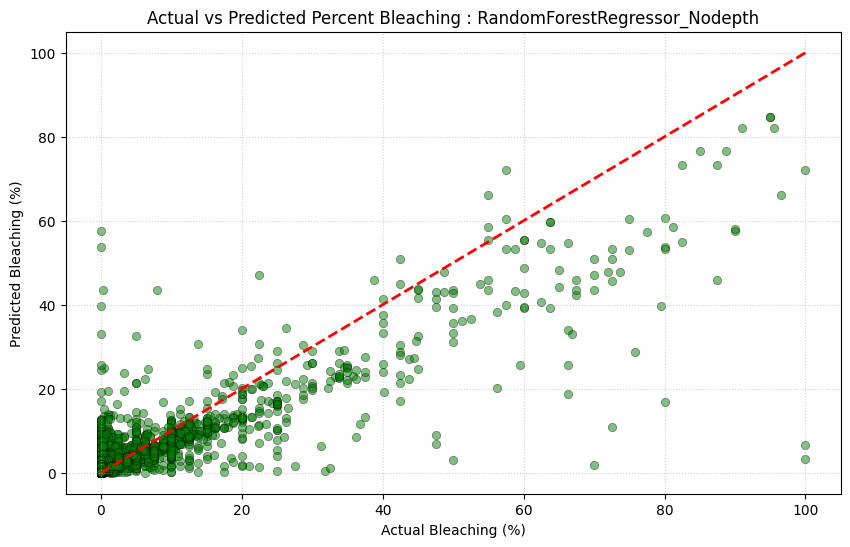


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.232319
0   Latitude_Degrees    0.216734
4     SSTA_X_ClimSST    0.209289
2            ClimSST    0.181987
3               SSTA    0.159671


In [156]:
all_results_model3th = []

for model, model_name, color in algo_model3th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model3th.values,
        target_model3th.values,
        model,
        n_splits=5
    )

    all_results_model3th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model3th.values,
        y_test=target_model3th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model3th)
print("\nFeature Importance:")
print(feature_importance_df)

##

##

---
# Model 4th : Model 2th + X2

In [157]:
factors_interaction_X2 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','La_X_SSTA']
feature_model4th = df_Interaction[factors_interaction_X2]
target_model4th = df_Interaction['Percent_Bleaching']

In [158]:
X_train_model4th, X_test_model4th, y_train_model4th, y_test_model4th = train_test_split(feature_model4th.values, target_model4th.values, test_size=0.2, random_state=42)

In [159]:
algo_model4th = [
    [RandomForestRegressor(max_features = 'log2', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 300, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2952
Fold MAE  : 3.2220
Fold R2   : 0.2011

===== Fold 2 / 5 =====
Fold RMSE : 8.2913
Fold MAE  : 3.3943
Fold R2   : 0.3224

===== Fold 3 / 5 =====
Fold RMSE : 7.9736
Fold MAE  : 3.1397
Fold R2   : 0.3559

===== Fold 4 / 5 =====
Fold RMSE : 7.7734
Fold MAE  : 3.0580
Fold R2   : 0.3045

===== Fold 5 / 5 =====
Fold RMSE : 7.3254
Fold MAE  : 3.1626
Fold R2   : 0.4092


Mean RMSE : 7.9318
Mean MAE  : 3.1953
Mean R2   : 0.3186


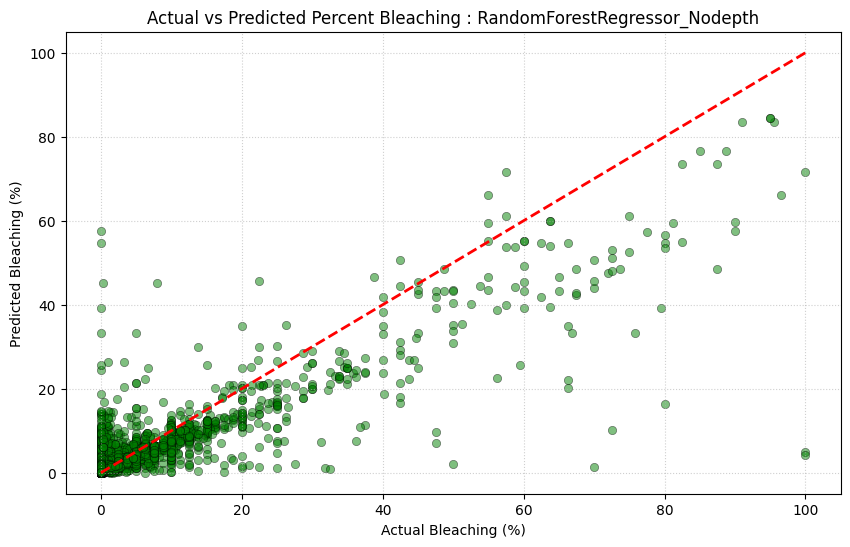


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.226408
4          La_X_SSTA    0.209242
0   Latitude_Degrees    0.203698
2            ClimSST    0.188591
3               SSTA    0.172061


In [160]:
all_results_model4th = []

for model, model_name, color in algo_model4th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model4th.values,
        target_model4th.values,
        model,
        n_splits=5
    )

    all_results_model4th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model4th.values,
        y_test=target_model4th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model4th)
print("\nFeature Importance:")
print(feature_importance_df)

##

##

---
# Model 5th : Model 2th + X3

In [161]:
factors_interaction_X3 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','La_X_ClimSST']
feature_model5th = df_Interaction[factors_interaction_X3]
target_model5th = df_Interaction['Percent_Bleaching']

In [162]:
X_train_model5th, X_test_model5th, y_train_model5th, y_test_model5th = train_test_split(feature_model5th.values, target_model5th.values, test_size=0.2, random_state=42)

In [163]:
algo_model5th = [
    [RandomForestRegressor(max_features = 'log2', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 300, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green']
]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3397
Fold MAE  : 3.2274
Fold R2   : 0.1925

===== Fold 2 / 5 =====
Fold RMSE : 8.3714
Fold MAE  : 3.3349
Fold R2   : 0.3092

===== Fold 3 / 5 =====
Fold RMSE : 8.0041
Fold MAE  : 3.1351
Fold R2   : 0.3510

===== Fold 4 / 5 =====
Fold RMSE : 7.7837
Fold MAE  : 3.0195
Fold R2   : 0.3026

===== Fold 5 / 5 =====
Fold RMSE : 7.3583
Fold MAE  : 3.1089
Fold R2   : 0.4039


Mean RMSE : 7.9714
Mean MAE  : 3.1652
Mean R2   : 0.3118


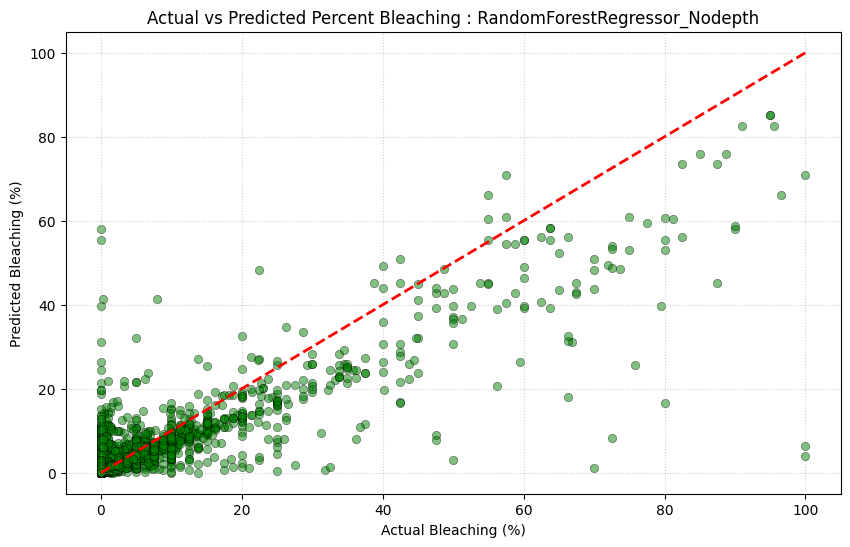


Feature Importance:
             feature  importance
4       La_X_ClimSST    0.238686
3               SSTA    0.202917
1  Longitude_Degrees    0.201309
0   Latitude_Degrees    0.181615
2            ClimSST    0.175473


In [164]:
all_results_model5th = []

for model, model_name, color in algo_model5th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model5th.values,
        target_model5th.values,
        model,
        n_splits=5
    )

    all_results_model5th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model5th.values,
        y_test=target_model5th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model5th)
print("\nFeature Importance:")
print(feature_importance_df)

##

##

---
## Model 6th : Model 2th + X4

In [189]:
factors_interaction_X4 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','Long_X_ClimSST']
feature_model6th = df_Interaction[factors_interaction_X4]
target_model6th = df_Interaction['Percent_Bleaching']

In [190]:
X_train_model6th, X_test_model6th, y_train_model6th, y_test_model6th = train_test_split(feature_model6th.values, target_model6th.values, test_size=0.2, random_state=42)

In [191]:
algo_model6th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 25, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.4772
Fold MAE  : 3.2439
Fold R2   : 0.1656

===== Fold 2 / 5 =====
Fold RMSE : 8.2082
Fold MAE  : 3.2767
Fold R2   : 0.3359

===== Fold 3 / 5 =====
Fold RMSE : 7.9057
Fold MAE  : 3.0958
Fold R2   : 0.3668

===== Fold 4 / 5 =====
Fold RMSE : 7.8523
Fold MAE  : 3.0375
Fold R2   : 0.2903

===== Fold 5 / 5 =====
Fold RMSE : 7.3332
Fold MAE  : 3.1193
Fold R2   : 0.4079


Mean RMSE : 7.9553
Mean MAE  : 3.1546
Mean R2   : 0.3133


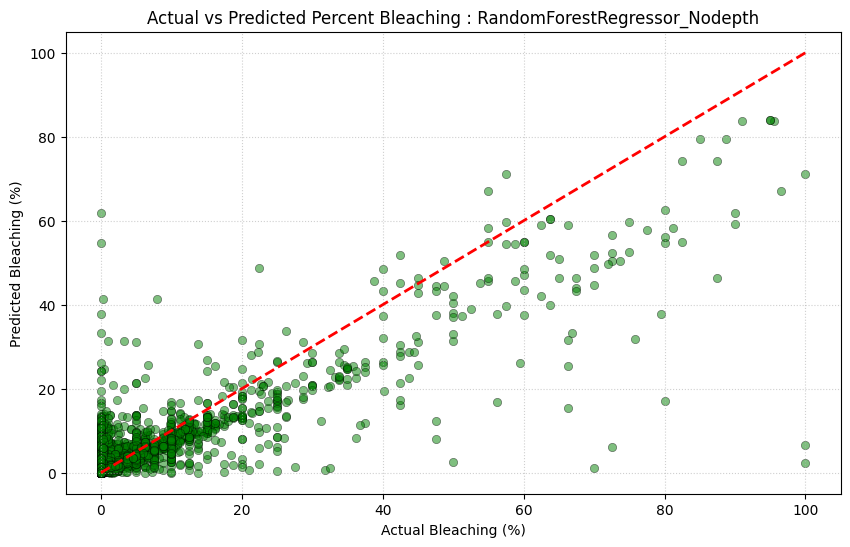


Feature Importance:
             feature  importance
4     Long_X_ClimSST    0.242548
1  Longitude_Degrees    0.205460
3               SSTA    0.199254
0   Latitude_Degrees    0.178415
2            ClimSST    0.174323


In [192]:
all_results_model6th = []

for model, model_name, color in algo_model6th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model6th.values,
        target_model6th.values,
        model,
        n_splits=5
    )

    all_results_model6th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model6th.values,
        y_test=target_model6th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model6th)
print("\nFeature Importance:")
print(feature_importance_df)

##

---
## Model 7th : Model 2th + X1 + X2

In [169]:
factors_interaction_X1X2 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','SSTA_X_ClimSST', 'La_X_SSTA']
feature_model7th = df_Interaction[factors_interaction_X1X2]
target_model7th = df_Interaction['Percent_Bleaching']

In [170]:
X_train_model8th, X_test_model8th, y_train_model8th, y_test_model8th = train_test_split(feature_model7th.values, target_model7th.values, test_size=0.2, random_state=42)

In [171]:
algo_model7th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 25, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2753
Fold MAE  : 3.2386
Fold R2   : 0.2049

===== Fold 2 / 5 =====
Fold RMSE : 8.3229
Fold MAE  : 3.4224
Fold R2   : 0.3172

===== Fold 3 / 5 =====
Fold RMSE : 8.0640
Fold MAE  : 3.1587
Fold R2   : 0.3412

===== Fold 4 / 5 =====
Fold RMSE : 7.8037
Fold MAE  : 3.0989
Fold R2   : 0.2990

===== Fold 5 / 5 =====
Fold RMSE : 7.2870
Fold MAE  : 3.1608
Fold R2   : 0.4154


Mean RMSE : 7.9506
Mean MAE  : 3.2159
Mean R2   : 0.3155


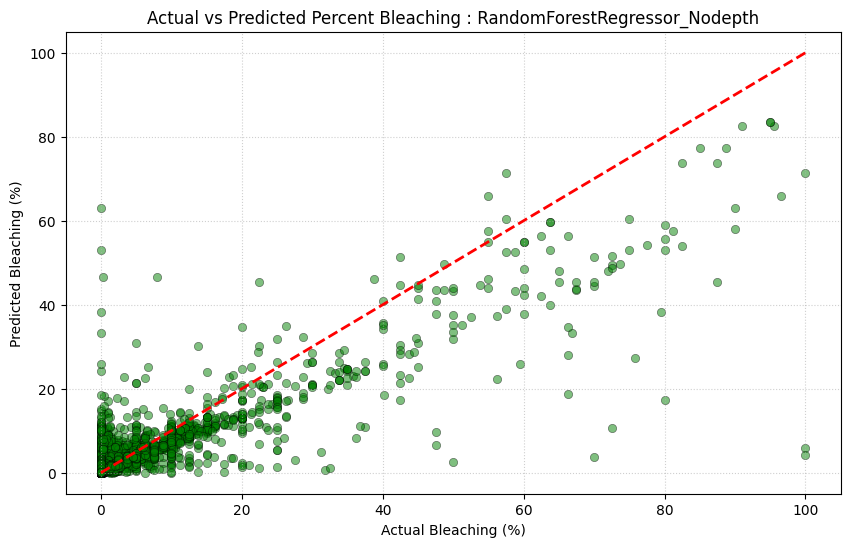


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.199173
0   Latitude_Degrees    0.177376
5          La_X_SSTA    0.173967
4     SSTA_X_ClimSST    0.166500
2            ClimSST    0.152482
3               SSTA    0.130503


In [172]:
all_results_model7th = []

for model, model_name, color in algo_model7th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model7th.values,
        target_model7th.values,
        model,
        n_splits=5
    )

    all_results_model7th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model7th.values,
        y_test=target_model7th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model7th)
print("\nFeature Importance:")
print(feature_importance_df)

##

---
## Model 9th : Model 2th + X1 + X2 + X3

In [173]:
factors_interaction_X1X2X3 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','SSTA_X_ClimSST','La_X_SSTA', 'La_X_ClimSST']
feature_model9th = df_Interaction[factors_interaction_X1X2X3]
target_model9th = df_Interaction['Percent_Bleaching']

In [174]:
X_train_model9th, X_test_model9th, y_train_model9th, y_test_model9th = train_test_split(feature_model9th.values, target_model9th.values, test_size=0.2, random_state=42)

In [175]:
algo_model9th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 25, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2658
Fold MAE  : 3.2255
Fold R2   : 0.2067

===== Fold 2 / 5 =====
Fold RMSE : 8.2730
Fold MAE  : 3.3582
Fold R2   : 0.3253

===== Fold 3 / 5 =====
Fold RMSE : 8.0002
Fold MAE  : 3.1312
Fold R2   : 0.3516

===== Fold 4 / 5 =====
Fold RMSE : 7.7867
Fold MAE  : 3.0938
Fold R2   : 0.3021

===== Fold 5 / 5 =====
Fold RMSE : 7.2795
Fold MAE  : 3.1426
Fold R2   : 0.4166


Mean RMSE : 7.9210
Mean MAE  : 3.1903
Mean R2   : 0.3205


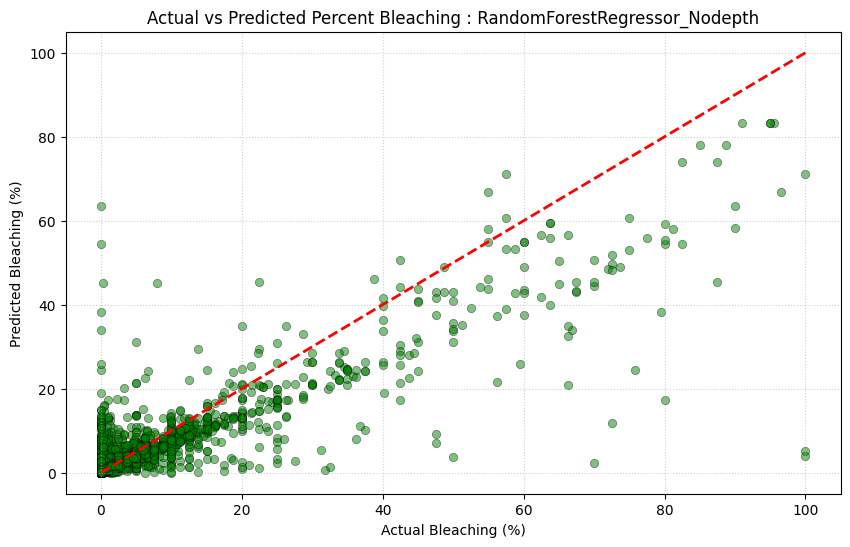


Feature Importance:
             feature  importance
6       La_X_ClimSST    0.171632
1  Longitude_Degrees    0.157325
0   Latitude_Degrees    0.146663
5          La_X_SSTA    0.143485
4     SSTA_X_ClimSST    0.141882
2            ClimSST    0.126734
3               SSTA    0.112279


In [176]:
all_results_model9th = []

for model, model_name, color in algo_model9th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model9th.values,
        target_model9th.values,
        model,
        n_splits=5
    )

    all_results_model9th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model9th.values,
        y_test=target_model9th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model9th)
print("\nFeature Importance:")
print(feature_importance_df)

##

---
## Model 11th : Model 2th + X1 + X2 + X3 + X4 + X5

In [185]:
factors_interaction_proposed = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','SSTA_X_ClimSST','La_X_SSTA', 'La_X_ClimSST','Long_X_ClimSST']
feature_model11th = df_Interaction[factors_interaction_proposed]
target_model11th = df_Interaction['Percent_Bleaching']

In [186]:
X_train_model11th, X_test_model11th, y_train_model11th, y_test_model11th = train_test_split(feature_model11th.values, target_model11th.values, test_size=0.2, random_state=42)

In [187]:
algo_model11th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 30, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2827
Fold MAE  : 3.2027
Fold R2   : 0.2035

===== Fold 2 / 5 =====
Fold RMSE : 8.2616
Fold MAE  : 3.3314
Fold R2   : 0.3272

===== Fold 3 / 5 =====
Fold RMSE : 7.9331
Fold MAE  : 3.0992
Fold R2   : 0.3624

===== Fold 4 / 5 =====
Fold RMSE : 7.7265
Fold MAE  : 3.0223
Fold R2   : 0.3128

===== Fold 5 / 5 =====
Fold RMSE : 7.2159
Fold MAE  : 3.1424
Fold R2   : 0.4267


Mean RMSE : 7.8840
Mean MAE  : 3.1596
Mean R2   : 0.3265


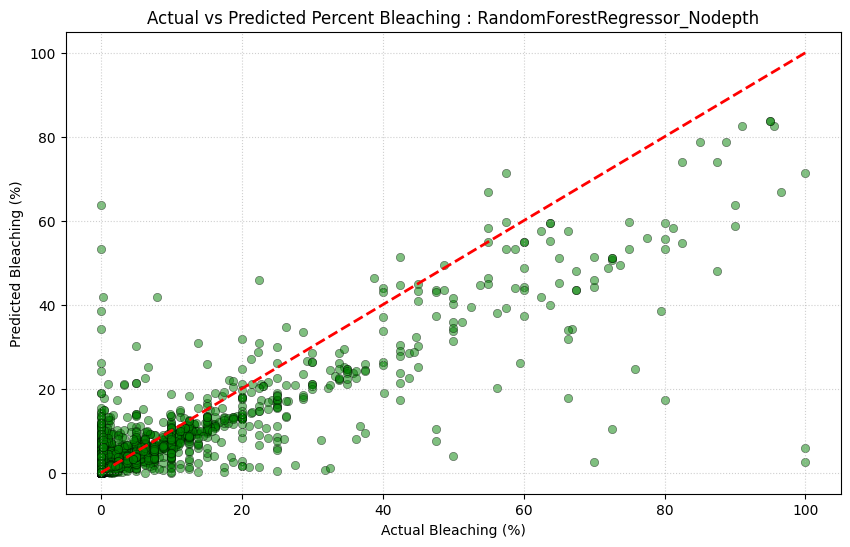


Feature Importance:
             feature  importance
7     Long_X_ClimSST    0.153421
6       La_X_ClimSST    0.146310
1  Longitude_Degrees    0.129379
5          La_X_SSTA    0.124813
4     SSTA_X_ClimSST    0.120340
0   Latitude_Degrees    0.117936
2            ClimSST    0.107225
3               SSTA    0.100576


In [188]:
all_results_model11th = []

for model, model_name, color in algo_model11th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model11th.values,
        target_model11th.values,
        model,
        n_splits=5
    )

    all_results_model11th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model11th.values,
        y_test=target_model11th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model11th)
print("\nFeature Importance:")
print(feature_importance_df)

##

In [211]:
factors_interaction_proposed = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','SSTA_X_ClimSST','La_X_SSTA']
feature_model14th = df_Interaction[factors_interaction_proposed]
target_model14th = df_Interaction['Percent_Bleaching']


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2688
Fold MAE  : 3.2390
Fold R2   : 0.2061

===== Fold 2 / 5 =====
Fold RMSE : 8.3112
Fold MAE  : 3.4232
Fold R2   : 0.3191

===== Fold 3 / 5 =====
Fold RMSE : 8.0879
Fold MAE  : 3.1576
Fold R2   : 0.3373

===== Fold 4 / 5 =====
Fold RMSE : 7.7942
Fold MAE  : 3.0870
Fold R2   : 0.3008

===== Fold 5 / 5 =====
Fold RMSE : 7.2686
Fold MAE  : 3.1442
Fold R2   : 0.4183


Mean RMSE : 7.9461
Mean MAE  : 3.2102
Mean R2   : 0.3163


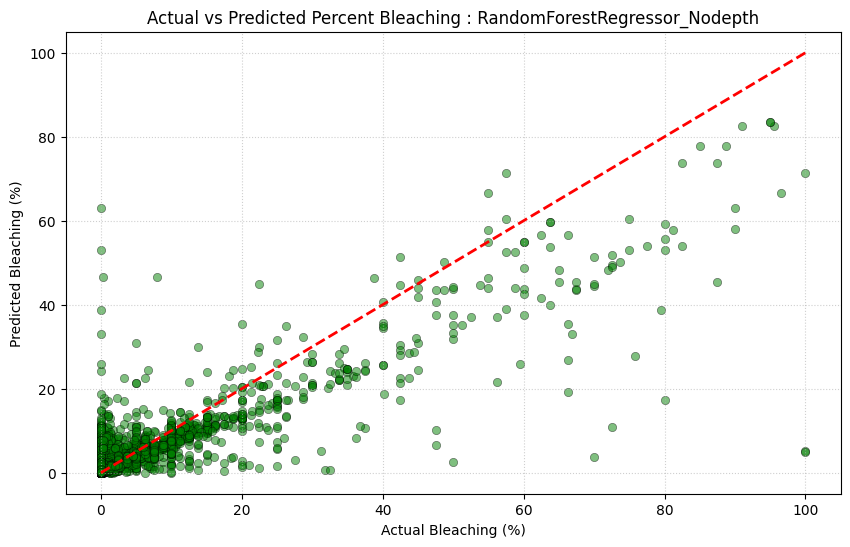


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.197813
0   Latitude_Degrees    0.177679
5          La_X_SSTA    0.171714
4     SSTA_X_ClimSST    0.167566
2            ClimSST    0.153922
3               SSTA    0.131306


In [212]:
all_results_model14th = []

for model, model_name, color in algo_model11th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model14th.values,
        target_model14th.values,
        model,
        n_splits=5
    )

    all_results_model11th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model14th.values,
        y_test=target_model14th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model14th)
print("\nFeature Importance:")
print(feature_importance_df)

##

---
## Model 10th : Model2th + X1 + X2 + X3 + Q1

In [181]:
factors_Q1 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','SSTA_X_ClimSST','La_X_SSTA', 'La_X_ClimSST','Long_X_ClimSST']
feature_model12th = df_Interaction[factors_Q1]
target_model12th = df_Interaction['Percent_Bleaching']

In [182]:
algo_model12th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 30, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2827
Fold MAE  : 3.2027
Fold R2   : 0.2035

===== Fold 2 / 5 =====
Fold RMSE : 8.2616
Fold MAE  : 3.3314
Fold R2   : 0.3272

===== Fold 3 / 5 =====
Fold RMSE : 7.9331
Fold MAE  : 3.0992
Fold R2   : 0.3624

===== Fold 4 / 5 =====
Fold RMSE : 7.7265
Fold MAE  : 3.0223
Fold R2   : 0.3128

===== Fold 5 / 5 =====
Fold RMSE : 7.2159
Fold MAE  : 3.1424
Fold R2   : 0.4267


Mean RMSE : 7.8840
Mean MAE  : 3.1596
Mean R2   : 0.3265


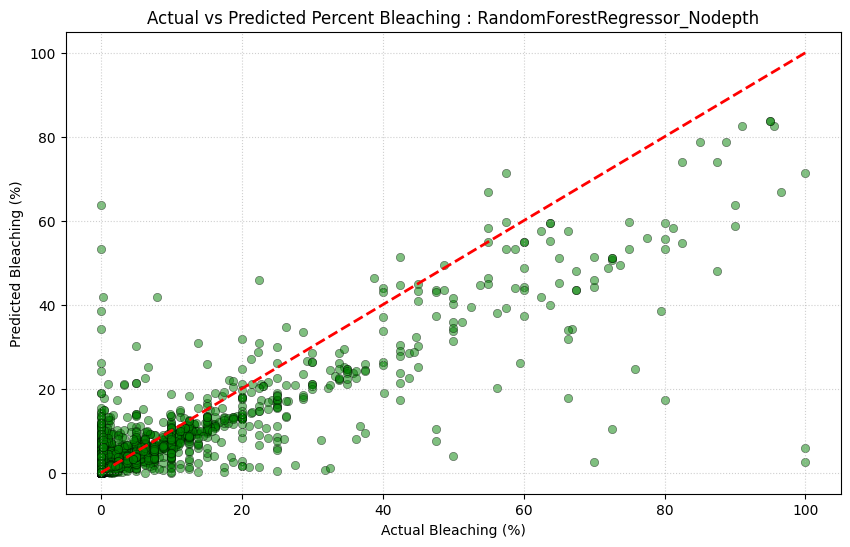


Feature Importance:
             feature  importance
7     Long_X_ClimSST    0.153421
6       La_X_ClimSST    0.146310
1  Longitude_Degrees    0.129379
5          La_X_SSTA    0.124813
4     SSTA_X_ClimSST    0.120340
0   Latitude_Degrees    0.117936
2            ClimSST    0.107225
3               SSTA    0.100576


In [183]:
all_results_model12th = []

for model, model_name, color in algo_model12th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model12th.values,
        target_model12th.values,
        model,
        n_splits=5
    )

    all_results_model12th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model12th.values,
        y_test=target_model12th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model12th)
print("\nFeature Importance:")
print(feature_importance_df)

##

##

In [184]:
factors_sqrtQ1 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','SSTA_X_ClimSST','La_X_SSTA', 'La_X_ClimSST','Sqrt_Q1']
feature_model13th = df_Interaction[factors_sqrtQ1]
target_model13th = df_Interaction['Percent_Bleaching']

KeyError: "['Sqrt_Q1'] not in index"

In [ ]:
algo_model13th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 30, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2829
Fold MAE  : 3.2028
Fold R2   : 0.2034

===== Fold 2 / 5 =====
Fold RMSE : 8.2614
Fold MAE  : 3.3311
Fold R2   : 0.3272

===== Fold 3 / 5 =====
Fold RMSE : 7.9328
Fold MAE  : 3.0990
Fold R2   : 0.3625

===== Fold 4 / 5 =====
Fold RMSE : 7.7266
Fold MAE  : 3.0226
Fold R2   : 0.3128

===== Fold 5 / 5 =====
Fold RMSE : 7.2150
Fold MAE  : 3.1420
Fold R2   : 0.4269


Mean RMSE : 7.8837
Mean MAE  : 3.1595
Mean R2   : 0.3266


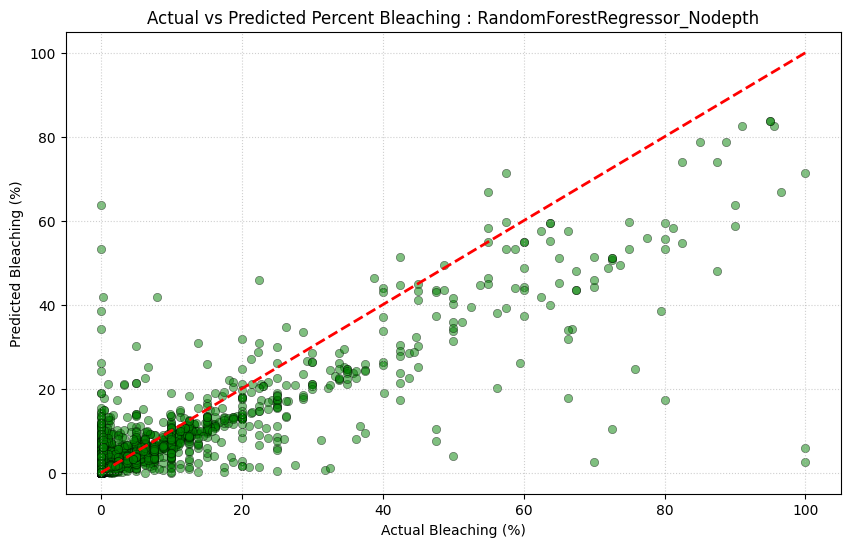


Feature Importance:
             feature  importance
7            Sqrt_Q1    0.153421
6       La_X_ClimSST    0.146310
1  Longitude_Degrees    0.129379
5          La_X_SSTA    0.124813
4     SSTA_X_ClimSST    0.120340
0   Latitude_Degrees    0.117936
2            ClimSST    0.107225
3               SSTA    0.100576


In [ ]:
all_results_model13th = []

for model, model_name, color in algo_model13th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model13th.values,
        target_model13th.values,
        model,
        n_splits=5
    )

    all_results_model13th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model13th.values,
        y_test=target_model13th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model13th)
print("\nFeature Importance:")
print(feature_importance_df)